# 06 - Visualize Technical Evaluation Results

This notebook builds summary plots from batch metrics.

Outputs are written to:
- `results/plots/summary/`
- `results/plots/summary/heatmaps/`


In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

plt.rcParams['figure.dpi'] = 130


In [54]:
ROOT = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains')
RUNS_PATH = ROOT / 'manifests' / 'runs.csv'
METRICS_PATH = ROOT / 'results' / 'metrics' / 'metrics_master.csv'

PLOT_DIR = ROOT / 'results' / 'plots' / 'summary'
HEATMAP_DIR = PLOT_DIR / 'heatmaps'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

assert RUNS_PATH.exists(), f'Missing runs manifest: {RUNS_PATH}'
assert METRICS_PATH.exists(), f'Missing metrics file: {METRICS_PATH}'

runs = pd.read_csv(RUNS_PATH)
metrics = pd.read_csv(METRICS_PATH)

print(f'runs rows: {len(runs)}')
print(f'metrics rows: {len(metrics)}')
print(f'unique metrics run_id: {metrics["run_id"].astype(str).nunique()}')


runs rows: 630
metrics rows: 624
unique metrics run_id: 624


In [64]:

metrics[metrics['F1_loss']==0]

,run_id,template_id,count_fraction,gene_panel,n_genes,mean_countsxcell,nmi,ari,F1_all,F1_gain,F1_loss,AUC_gains,PR_gains,AUC_loss,PR_loss
0,T01_C1_G1000,T01,1,1000,1000,28.032335,0.010155,0.010352,0.076275,0.159449,0.0,0.527417,0.006067,0.510551,0.010201
1,T01_C1_G10000,T01,1,10000,10000,138.865936,0.180122,0.174528,0.247986,0.543705,0.0,0.667095,0.046968,0.535073,0.012831
4,T01_C1_G500,T01,1,500,500,8.569401,0.001510,-0.002626,0.033841,0.045516,0.0,0.500257,0.007601,0.505290,0.010525
5,T01_C1_G5000,T01,1,5000,5000,83.883278,0.009832,0.000709,0.146742,0.337371,0.0,0.569139,0.009319,0.532471,0.013694
7,T01_C2_G1000,T01,2,1000,1000,55.941639,0.006341,0.002382,0.107017,0.244370,0.0,0.550945,0.007378,0.516972,0.010371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,T10_C2_G500,T10,2,500,500,17.197161,0.009951,0.007098,0.078521,0.190987,0.0,0.539649,0.020591,0.511773,0.032231
574,T10_C2_G5000,T10,2,5000,5000,174.070190,0.566493,0.573300,0.297647,0.581537,0.0,0.692395,0.141453,0.534008,0.027572
576,T10_C3_G1000,T10,3,1000,1000,87.548897,0.307766,0.313118,0.183288,0.355857,0.0,0.588334,0.056203,0.517741,0.025268
581,T10_C3_G5000,T10,3,5000,5000,261.361206,0.640847,0.643911,0.319583,0.620769,0.0,0.715665,0.187406,0.533050,0.027506


In [65]:
print(df_counts.columns.tolist())

['run_id', 'template_id', 'count_fraction', 'gene_panel', 'status', 'n_genes', 'mean_countsxcell', 'nmi', 'ari', 'F1_all', 'F1_gain', 'F1_loss', 'AUC_gains', 'PR_gains', 'AUC_loss', 'PR_loss', 'has_metrics']


In [66]:
for col in ['ari', 'nmi', 'F1_all', 'F1_gain', 'F1_loss', 'AUC_gains', 'AUC_loss']:
    print(col, col in df_counts.columns)

ari True
nmi True
F1_all True
F1_gain True
F1_loss True
AUC_gains True
AUC_loss True


In [67]:
df_counts

,run_id,template_id,count_fraction,gene_panel,status,n_genes,mean_countsxcell,nmi,ari,F1_all,F1_gain,F1_loss,AUC_gains,PR_gains,AUC_loss,PR_loss,has_metrics
0,T01_C1_G1000,T01,1,1000,inferred,1000.0,28.032335,0.010155,0.010352,0.076275,0.159449,0.000000,0.527417,0.006067,0.510551,0.010201,True
1,T01_C1_G10000,T01,1,10000,inferred,10000.0,138.865936,0.180122,0.174528,0.247986,0.543705,0.000000,0.667095,0.046968,0.535073,0.012831,True
2,T01_C1_G15000,T01,1,15000,inferred,15000.0,210.013412,0.277569,0.325056,0.324697,0.663805,0.008886,0.739497,0.111861,0.535388,0.012728,True
3,T01_C1_G20000,T01,1,20000,inferred,20000.0,287.126190,0.300779,0.317375,0.326175,0.669319,0.012545,0.745061,0.133093,0.534232,0.012769,True
4,T01_C1_G500,T01,1,500,inferred,500.0,8.569401,0.001510,-0.002626,0.033841,0.045516,0.000000,0.500257,0.007601,0.505290,0.010525,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,T10_C100_G15000,T10,100,15000,inferred,15000.0,21454.380859,0.992235,0.995843,0.831058,0.791661,0.856464,0.838815,0.594577,0.885221,0.661043,True
626,T10_C100_G20000,T10,100,20000,inferred,20000.0,29297.142578,0.996146,0.998041,0.862069,0.833142,0.880234,0.867642,0.662990,0.902952,0.711900,True
627,T10_C100_G500,T10,100,500,inferred,500.0,859.024048,0.257471,0.204134,0.185289,0.315910,0.097321,0.593185,0.102279,0.529059,0.032886,True
628,T10_C100_G5000,T10,100,5000,inferred,5000.0,8663.318359,0.962612,0.972348,0.705356,0.699486,0.708321,0.780554,0.446961,0.785466,0.387021,True


## Standardize Ordering And Merge Status

We standardize panel/count ordering, then merge run status into metrics so all plots can show missing/failed runs explicitly.


In [3]:
count_order = [100, 70, 50, 20, 10, 5, 3, 2, 1]
gene_order = ['all', '20000', '15000', '10000', '5000', '1000', '500']

runs['run_id'] = runs['run_id'].astype(str)
metrics['run_id'] = metrics['run_id'].astype(str)

runs['count_fraction'] = pd.to_numeric(runs['count_fraction'], errors='coerce')
runs['gene_panel'] = runs['gene_panel'].astype(str)
metrics['count_fraction'] = pd.to_numeric(metrics['count_fraction'], errors='coerce')
metrics['gene_panel'] = metrics['gene_panel'].astype(str)

runs['count_fraction'] = pd.Categorical(runs['count_fraction'], categories=count_order, ordered=True)
runs['gene_panel'] = pd.Categorical(runs['gene_panel'], categories=gene_order, ordered=True)
metrics['count_fraction'] = pd.Categorical(metrics['count_fraction'], categories=count_order, ordered=True)
metrics['gene_panel'] = pd.Categorical(metrics['gene_panel'], categories=gene_order, ordered=True)

status_cols = ['run_id', 'template_id', 'count_fraction', 'gene_panel']
if 'status' in runs.columns:
    status_cols.append('status')
else:
    runs['status'] = 'unknown'
    status_cols.append('status')

merged = runs[status_cols].merge(
    metrics,
    on=['run_id', 'template_id', 'count_fraction', 'gene_panel'],
    how='left',
    suffixes=('_run', '')
)

merged['has_metrics'] = merged['ari'].notna()
print(merged[['status', 'has_metrics']].value_counts(dropna=False).to_string())


status    has_metrics
inferred  True           621
failed    False            6
          True             3


## 1) Run Completeness Matrix

Shows, for each technical condition, how many runs are inferred and how many have computed metrics.


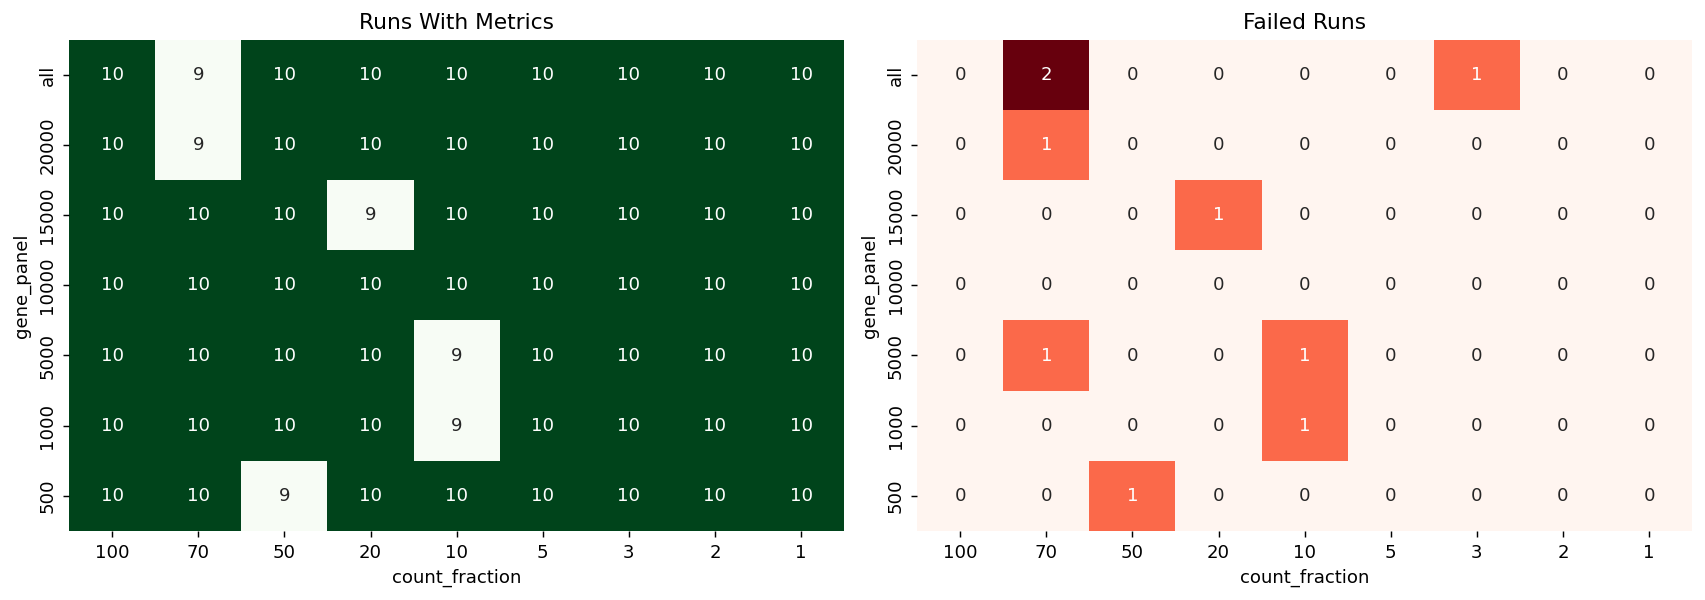

In [4]:
summary = (
    merged
    .groupby(['count_fraction', 'gene_panel'], observed=False)
    .agg(
        n_runs=('run_id', 'count'),
        n_inferred=('status', lambda x: int((x.astype(str).str.lower() == 'inferred').sum())),
        n_failed=('status', lambda x: int((x.astype(str).str.lower() == 'failed').sum())),
        n_with_metrics=('has_metrics', lambda x: int(x.sum())),
    )
    .reset_index()
)

pivot_metrics = summary.pivot(index='gene_panel', columns='count_fraction', values='n_with_metrics')
pivot_failed = summary.pivot(index='gene_panel', columns='count_fraction', values='n_failed')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

if sns is not None:
    sns.heatmap(pivot_metrics, annot=True, fmt='.0f', cmap='Greens', ax=axes[0], cbar=False)
    sns.heatmap(pivot_failed, annot=True, fmt='.0f', cmap='Reds', ax=axes[1], cbar=False)
else:
    im0 = axes[0].imshow(pivot_metrics.fillna(0).values, aspect='auto', cmap='Greens')
    im1 = axes[1].imshow(pivot_failed.fillna(0).values, aspect='auto', cmap='Reds')
    axes[0].set_yticks(range(len(pivot_metrics.index))); axes[0].set_yticklabels(pivot_metrics.index)
    axes[1].set_yticks(range(len(pivot_failed.index))); axes[1].set_yticklabels(pivot_failed.index)
    axes[0].set_xticks(range(len(pivot_metrics.columns))); axes[0].set_xticklabels(pivot_metrics.columns)
    axes[1].set_xticks(range(len(pivot_failed.columns))); axes[1].set_xticklabels(pivot_failed.columns)

axes[0].set_title('Runs With Metrics')
axes[1].set_title('Failed Runs')
for ax in axes:
    ax.set_xlabel('count_fraction')
    ax.set_ylabel('gene_panel')

fig.savefig(PLOT_DIR / 'completeness_heatmaps.png', dpi=220)
plt.show()


## 2) Performance Trends Across Count Fraction

Each panel tracks one metric vs count fraction.
Lines are averaged across templates, one line per gene panel.


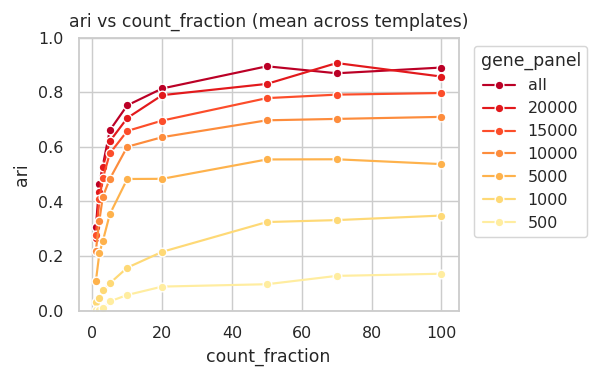

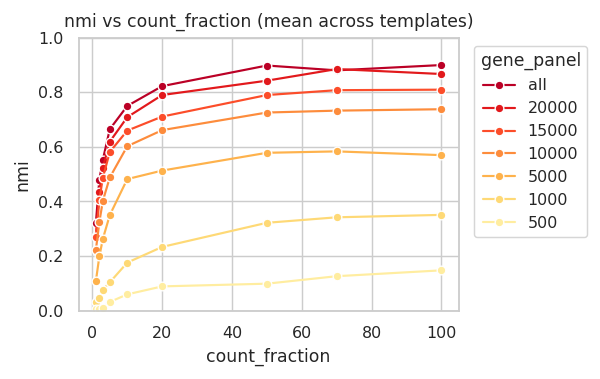

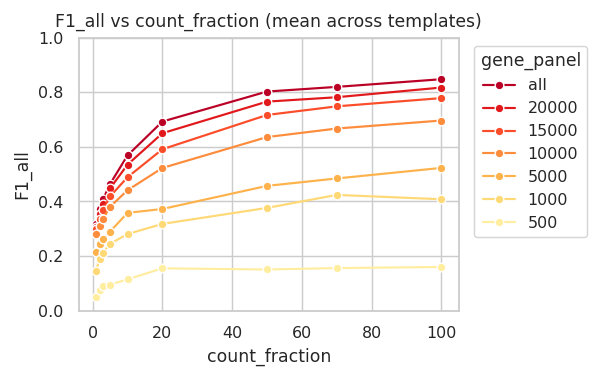

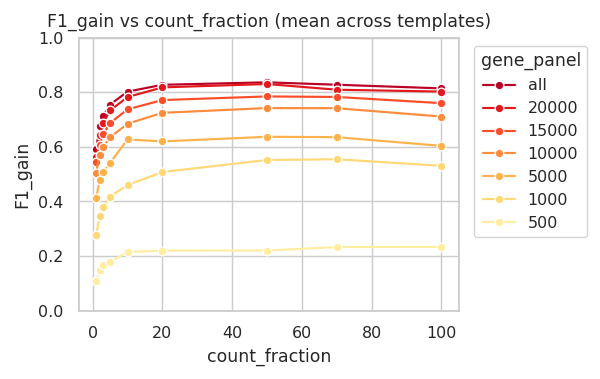

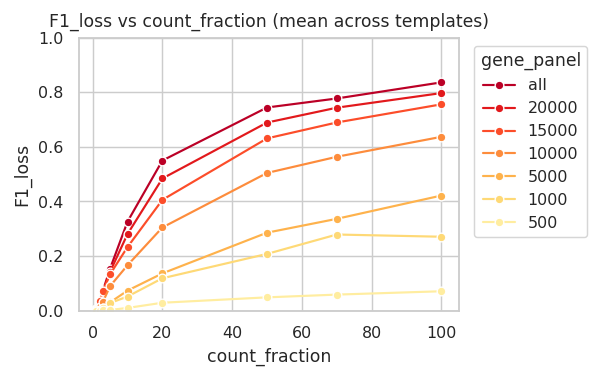

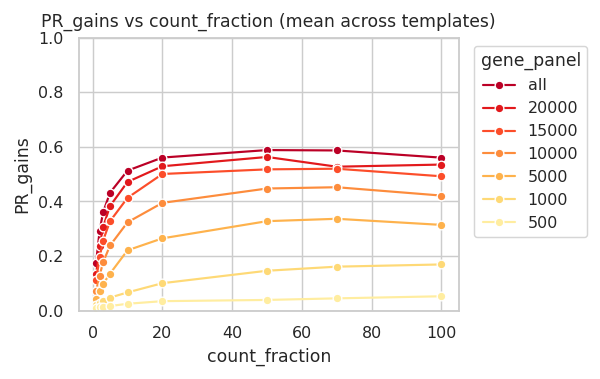

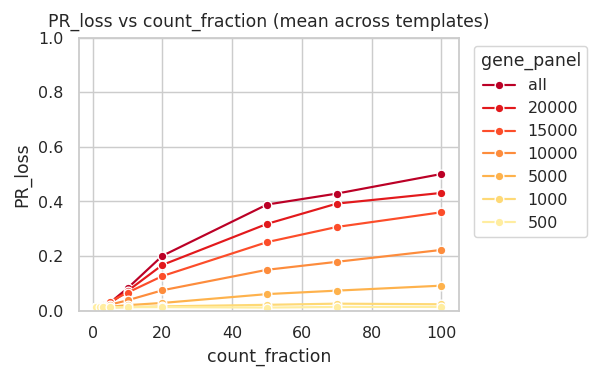

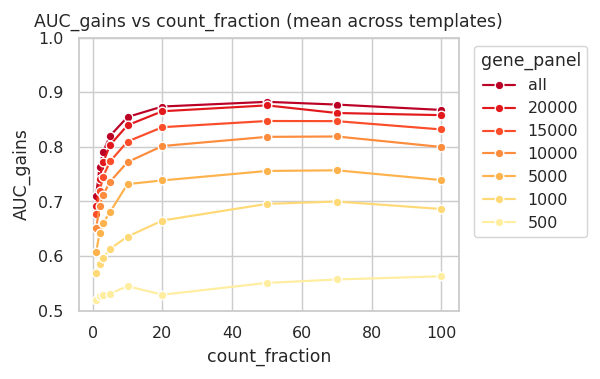

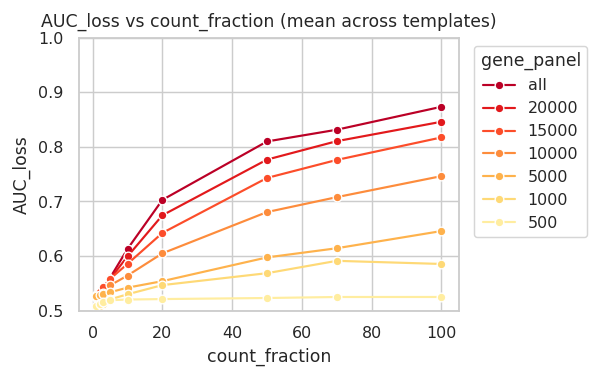

In [72]:
plot_metrics = [
    'ari', 'nmi', 'F1_all', 'F1_gain', 'F1_loss',
    'PR_gains', 'PR_loss', 'AUC_gains', 'AUC_loss'
]

df = merged[merged['has_metrics']].copy()
for m in plot_metrics:
    df[m] = pd.to_numeric(df[m], errors='coerce')

palette = sns.color_palette("YlOrRd", n_colors=len(gene_order))[::-1]
#color_map = dict(zip(map(str, gene_order), palette))

for metric in plot_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.8), constrained_layout=True)
    if sns is not None:
        sns.lineplot(
            data=df,
            x='count_fraction',
            y=metric,
            hue='gene_panel',
            marker='o',
            estimator='mean',
            errorbar=None,
            palette=palette,
            ax=ax,
        )
    else:
        grp = (
            df.groupby(['gene_panel', 'count_fraction'], observed=False)[metric]
            .mean()
            .reset_index()
        )
        for gp, sub in grp.groupby('gene_panel', observed=False):
            ax.plot(sub['count_fraction'].astype(str), sub[metric], marker='o', label=str(gp))
    #ax.set_xscale('log')
    ax.set_title(f'{metric} vs count_fraction (mean across templates)')
    ax.set_xlabel('count_fraction')
    ax.set_ylabel(metric)

    if metric in ['ari', 'nmi', 'F1_all', 'F1_gain', 'F1_loss', 'PR_gains', 'PR_loss']:
        ax.set_ylim(0, 1)
    if metric in ['AUC_gains', 'AUC_loss']:
        ax.set_ylim(0.5, 1)
        
    ax.legend(title='gene_panel', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.savefig(PLOT_DIR / f'metric_vs_countfrac_{metric}.svg', dpi=220)
    plt.show()

## 2b) Performance Trends Across Mean Counts Per Cell

Same metrics as above, but x-axis is `mean_countsxcell` instead of `count_fraction`.
Curves are still averaged across templates and split by gene panel.


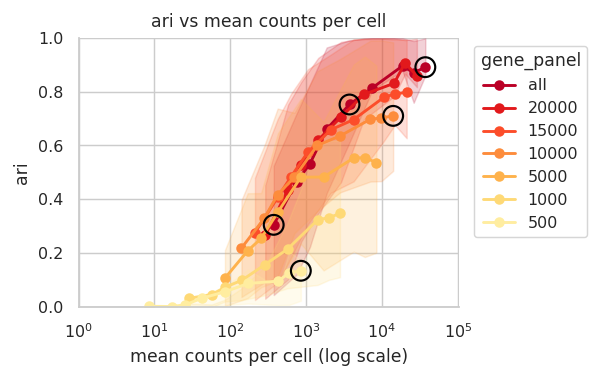

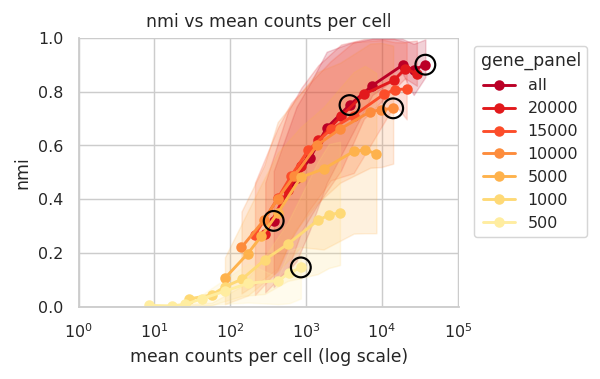

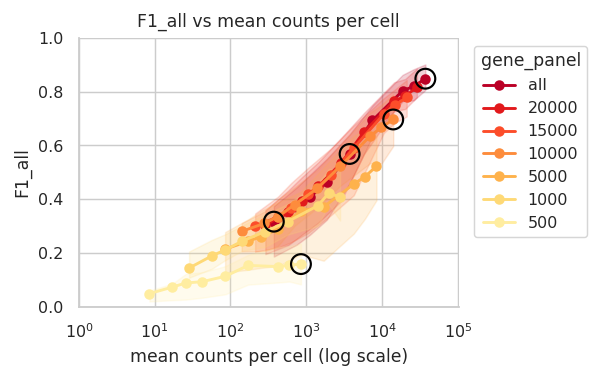

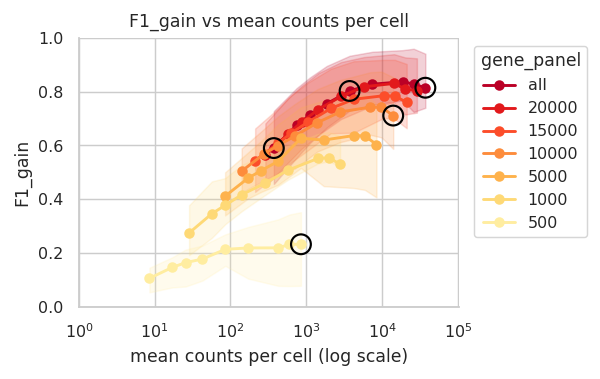

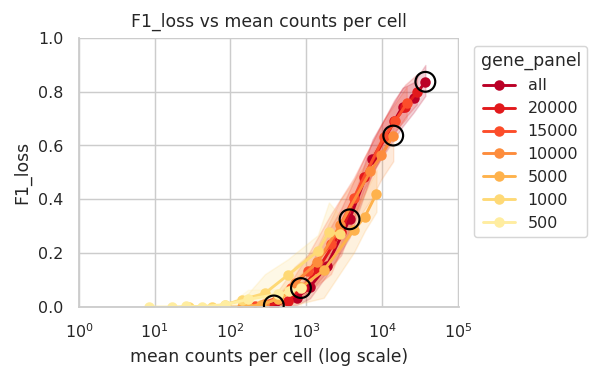

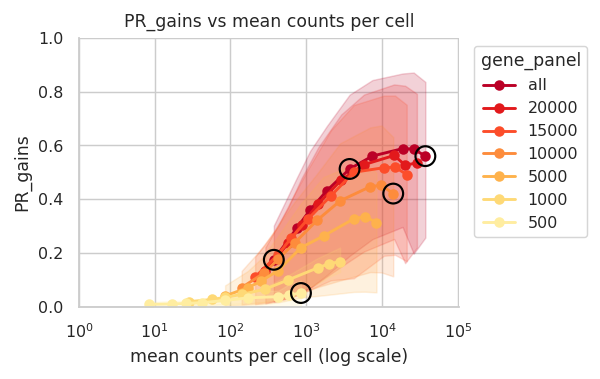

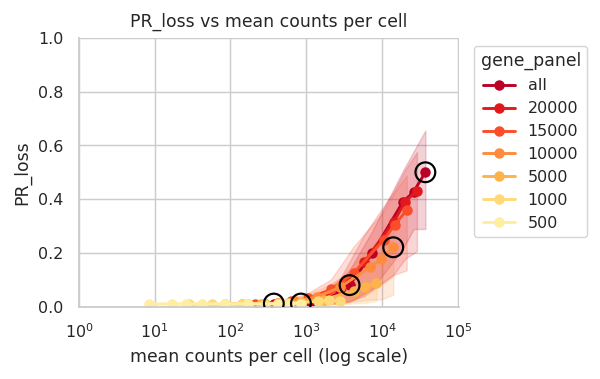

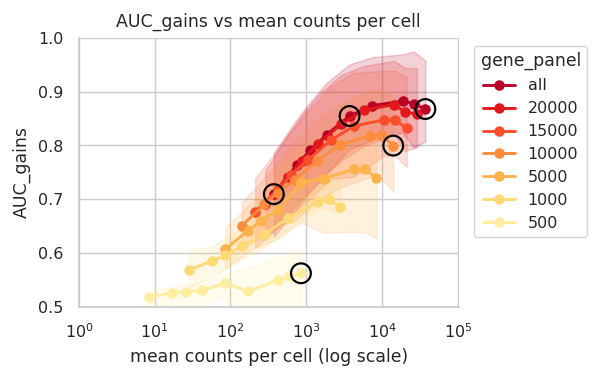

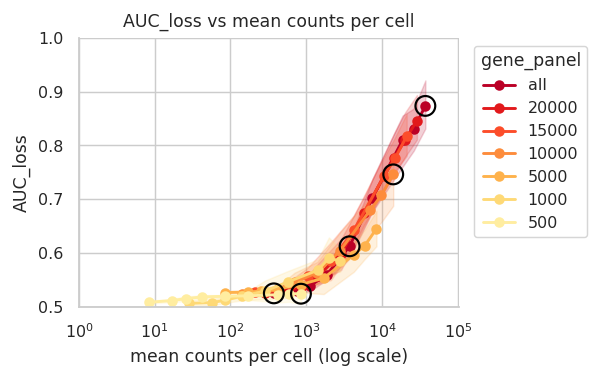

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_metrics_counts = [
    'ari', 'nmi', 'F1_all', 'F1_gain', 'F1_loss',
    'PR_gains', 'PR_loss', 'AUC_gains', 'AUC_loss'
]

df_counts = merged[merged['has_metrics']].copy()
for m in plot_metrics_counts + ['mean_countsxcell']:
    df_counts[m] = pd.to_numeric(df_counts[m], errors='coerce')

# Keep template-level rows; summarize distribution across templates per condition
agg = (
    df_counts.groupby(['template_id', 'gene_panel', 'count_fraction'], observed=False)
    .agg({
        'mean_countsxcell': 'mean',
        'ari': 'mean',
        'nmi': 'mean',
        'F1_all': 'mean',
        'F1_gain': 'mean',
        'F1_loss': 'mean',
        'PR_gains': 'mean',
        'PR_loss': 'mean',
        'AUC_gains': 'mean',
        'AUC_loss': 'mean',
    })
    .reset_index()
)

sns.set_style("whitegrid")
sns.set_context("paper")

palette = sns.color_palette("YlOrRd", n_colors=len(gene_order))[::-1]
color_map = dict(zip(map(str, gene_order), palette))

boxed_cells = [
    ("all", 1),
    ("all", 10),
    #("10000", 10),
    ("all", 100),
    ("10000", 100),
    ("500", 100),
]

for metric in plot_metrics_counts:
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.8), constrained_layout=True)

    for gp in gene_order:
        sub = agg[agg['gene_panel'].astype(str) == str(gp)].copy()
        if len(sub) == 0:
            continue

        stats = (
            sub.groupby('count_fraction', observed=False)
            .agg(
                x=('mean_countsxcell', 'mean'),
                y_mean=(metric, 'mean'),
                y_q25=(metric, lambda z: z.quantile(0.25)),
                y_q75=(metric, lambda z: z.quantile(0.75)),
                y_min=(metric, 'min'),
                y_max=(metric, 'max'),
            )
            .reset_index()
            .dropna(subset=['x', 'y_mean'])
            .sort_values('x')
        )

        if len(stats) == 0:
            continue

        color = color_map[str(gp)]

        ax.plot(
            stats['x'],
            stats['y_mean'],
            marker='o',
            linewidth=1.6,
            color=color,
            label=str(gp),
        )

        ax.fill_between(
            stats['x'],
            stats['y_q25'],
            stats['y_q75'],
            color=color,
            alpha=0.18,
        )

        # circle selected points
        for gp_box, cf_box in boxed_cells:
            if str(gp) != str(gp_box):
                continue

            row = stats[stats["count_fraction"] == cf_box]
            if len(row) == 0:
                continue

            x_val = row["x"].values[0]
            y_val = row["y_mean"].values[0]

            ax.scatter(
                x_val,
                y_val,
                s=120,
                facecolors='none',
                edgecolors='black',
                linewidths=1.2,
                zorder=5,
            )

    ax.set_xscale('log')
    ax.set_xlabel('mean counts per cell (log scale)')
    ax.set_ylabel(metric)
    ax.set_xlim(1, 103_000)

    if metric in ['ari', 'nmi', 'F1_all', 'F1_gain', 'F1_loss', 'PR_gains', 'PR_loss']:
        ax.set_ylim(0, 1)
    if metric in ['AUC_gains', 'AUC_loss']:
        ax.set_ylim(0.5, 1)

    ax.set_title(f'{metric} vs mean counts per cell')
    ax.legend(title='gene_panel', bbox_to_anchor=(1.02, 1), loc='upper left')
    sns.despine()

    fig.savefig(PLOT_DIR / f'metric_vs_logcountsxcell_{metric}.svg', dpi=220)
    plt.show()

## 3) Show Missing-Run Table

Useful for deciding whether to rerun inferCNV on failed conditions.


In [76]:
missing = merged[~merged['has_metrics']].copy()
missing = missing[['run_id', 'template_id', 'count_fraction', 'gene_panel', 'status']].sort_values(
    ['template_id', 'count_fraction', 'gene_panel']
)
missing_out = PLOT_DIR / 'runs_missing_metrics.csv'
missing.to_csv(missing_out, index=False)

print(f'Missing metrics rows: {len(missing)}')
print(f'Saved: {missing_out}')
display(missing.head(30))

Missing metrics rows: 6
Saved: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/plots/summary/runs_missing_metrics.csv


,run_id,template_id,count_fraction,gene_panel,status
115,T02_C70_G20000,T02,70,20000,failed
222,T04_C10_G5000,T04,10,5000,failed
370,T06_C70_Gall,T06,70,all,failed
352,T06_C20_G15000,T06,20,15000,failed
343,T06_C10_G1000,T06,10,1000,failed
613,T10_C50_G500,T10,50,500,failed
